# 🚦 VisionMaroor: Intelligent Traffic Sign Analysis & Voice Guidance System

**Project Type:** B.Tech Graduation Project  
**Domain:** Artificial Intelligence, Computer Vision, and Natural Language Processing (NLP)

## 📌 Project Overview
Welcome to **VisionMaroor**, an advanced, end-to-end Artificial Intelligence system designed to enhance road safety and driver awareness. Traditional traffic sign recognition models stop at mere classification. VisionMaroor goes a step further by bridging the gap between raw Computer Vision predictions and real-time human interaction, simulating a smart in-car driving assistant.

## 🎯 What We Will Do in This Project
In this notebook, we will build a comprehensive, production-ready AI pipeline through the following phases:

1. **Robust Data Processing:** Loading and augmenting a complex dataset of 58 distinct traffic sign classes to ensure the model generalizes well to real-world driving conditions.
2. **Advanced Computer Vision (Transfer Learning):** Utilizing the state-of-the-art **EfficientNetB0** architecture pre-trained on ImageNet. We will apply Fine-tuning, Dropout, and L2 Regularization to build a highly accurate Classification CNN while preventing overfitting.
3. **Optimized Training Strategy:** Implementing dynamic training callbacks including `EarlyStopping`, `ReduceLROnPlateau`, and `ModelCheckpoint` to achieve the highest possible accuracy efficiently.
4. **NLP Logic Layer Integration:** Mapping numerical predictions to a dynamic dictionary using the dataset's `labels.csv`, translating raw classes into meaningful, context-aware English sentences.
5. **Text-to-Speech (TTS) Simulation:** Integrating Google TTS (`gTTS`) to convert the generated text into real-time audio alerts, completing the cycle from visual perception to auditory guidance.

## 🚀 Future Vision
The architecture of VisionMaroor is modular by design. The final trained model can be easily exported to **TensorFlow Lite (TFLite)**, making it fully prepared for deployment on mobile applications (e.g., via Flutter) or edge devices (IoT) within smart vehicles.

##  Preparatory step: Implementing the restrictions (dependencies and requirements)

In [1]:
%%writefile requirements.txt
tensorflow>=2.10.0
numpy
pandas
matplotlib
seaborn
scikit-learn
gTTS
opencv-python
IPython

Writing requirements.txt


## 🛠️ Step 1: Environment Setup and Dependency Installation

In this initial step, we configure our cloud development environment by installing necessary external dependencies that are not pre-installed. Specifically, we are installing the **`gTTS` (Google Text-to-Speech)** library. 

In [2]:
# Cell 1: Installations
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


## 📦 Step 2: Architectural Foundation (Library Imports)

In this cell, we establish the computational foundation of the **VisionMaroor** project by importing all necessary libraries and frameworks. 

In [3]:
# Cell 2: Imports & Configuration
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report
from gtts import gTTS
from IPython.display import Audio, display
print("TensorFlow Version:", tf.__version__)


2026-03-01 22:36:22.748192: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772404583.174812      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772404583.318564      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772404584.360163      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772404584.360203      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772404584.360205      24 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


## ⚙️ Step 3: Global Configuration and Hyperparameter Initialization

In this section, we define the global variables, file paths, and Deep Learning hyperparameters. Centralizing these configurations ensures the project remains modular, scalable, and highly maintainable. 

**Engineering Objective:**
By isolating the configuration parameters from the core logic, we establish a clean experimentation environment.

In [4]:

# Cell 3: Configuration 
KAGGLE_INPUT_PATH = "/kaggle/input/datasets/seebicb/traffic-signs-classification/traffic_Data" 
TRAIN_DIR = os.path.join(KAGGLE_INPUT_PATH, "DATA")
TEST_DIR = os.path.join(KAGGLE_INPUT_PATH, "test")  

MODEL_SAVE_PATH = "vision_maroor_efficientnet.h5"

IMG_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 51 
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3

## 📊 Step 4: Data Preparation and Augmentation Strategy

In this stage, we construct the data pipeline using Keras's `ImageDataGenerator`. This module is responsible for loading the image data in efficient batches, normalizing the pixel values, and applying real-time data augmentation.

In [5]:
# Cell 4: Data Preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2 
)

print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

print("\nLoading Validation Data:")
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Loading Training Data:
Found 3348 images belonging to 58 classes.

Loading Validation Data:
Found 808 images belonging to 58 classes.


## 🧠 Step 5: Deep Learning Architecture and Transfer Learning

In this critical phase, we construct the neural network that serves as the "brain" of the **VisionMaroor** system. Instead of training a model from scratch—which requires massive computational resources and time—we employ a highly effective technique known as **Transfer Learning**.

In [6]:
# Cell 5: Model Building (Transfer Learning)
DYNAMIC_NUM_CLASSES = train_generator.num_classes
print(f"Building model for {DYNAMIC_NUM_CLASSES} classes...")

def build_model():
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    base_model.trainable = False 

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    
    predictions = Dense(DYNAMIC_NUM_CLASSES, activation='softmax')(x) 

    model = Model(inputs=base_model.input, outputs=predictions)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()

Building model for 58 classes...


I0000 00:00:1772404621.979706      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772404621.986239      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## ⏳ Step 6: Model Training and Dynamic Optimization Strategy

With our architecture defined and data pipelines ready, we initiate the training phase. Training a Deep Learning model requires careful monitoring to ensure it learns generalized features rather than simply memorizing the training dataset (Overfitting). 

In [7]:
# Cell 6: Training Execution
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50, 
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1772404638.101197      88 service.cc:152] XLA service 0x7e0648015540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772404638.101234      88 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772404638.101240      88 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772404640.636022      88 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-01 22:37:28.894996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 22:37:29.038134: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 22:37:29.381274: E external/local_xl

  6/105 ━━━━━━━━━━━━━━━━━━━━ 46s 473ms/step - accuracy: 0.0069 - loss: 9.2325

2026-03-01 22:37:48.286935: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 22:37:48.428126: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 22:37:48.758217: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 22:37:48.900216: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 22:37:49.651895: E external/local_xla/xla/stream_

...


Epoch 1: val_accuracy improved from -inf to 0.03837, saving model to vision_maroor_efficientnet.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 135s 997ms/step - accuracy: 0.0265 - loss: 8.3018 - val_accuracy: 0.0384 - val_loss: 5.7320 - learning_rate: 0.0010
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.0411 - loss: 5.8736
Epoch 2: val_accuracy improved from 0.03837 to 0.06436, saving model to vision_maroor_efficientnet.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 500ms/step - accuracy: 0.0412 - loss: 5.8703 - val_accuracy: 0.0644 - val_loss: 4.5160 - learning_rate: 0.0010
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.0557 - loss: 4.7565
Epoch 3: val_accuracy improved from 0.06436 to 0.10644, saving model to vision_maroor_efficientnet.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 505ms/step - accuracy: 0.0557 - loss: 4.7553 - val_accuracy: 0.1064 - val_loss: 4.0151 - learning_rate: 0.0010
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.0609 - loss: 4.3562
Epoch 4: val_accuracy did not improve from 0.10644
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 496ms/step - accuracy: 0.0610 - loss: 4.3556 - val_accuracy: 0.0792 - val_loss: 3.8310 - learning_rate: 0.0010
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.0768 - loss: 4.1231
Epoch 5: val_accuracy improved from 0.10644 to 0.12129, saving model to vision_maroor_efficientnet.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 502ms/step - accuracy: 0.0768 - loss: 4.1229 - val_accuracy: 0.1213 - val_loss: 3.7445 - learning_rate: 0.0010
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.0754 - loss: 4.0487
Epoch 6: val_accuracy did not improve from 0.12129
105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 503ms/step - accuracy: 0.0755 - loss: 4.0485 - val_accuracy: 0.0792 - val_loss: 3.7066 - learning_rate: 0.0010
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.0757 - loss: 3.9644
Epoch 7: val_accuracy did not improve from 0.12129
105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 503ms/step - accuracy: 0.0757 - loss: 3.9645 - val_accuracy: 0.1064 - val_loss: 3.6755 - learning_rate: 0.0010
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.0842 - loss: 3.9568
Epoch 8: val_accuracy did not improve from 0.12129
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 497ms/step - accuracy: 0.0842 - loss: 3.9565 - val_accuracy: 0.1064 - val_loss: 3.6634 - learning_rate: 0.0010
Epoch 9

## 📉 Step 7: Model Evaluation and Visual Diagnostics

Following the completion of the training phase, it is critical to evaluate the neural network's learning behavior visually. This cell extracts the telemetry data captured continuously by the Keras `history` object to generate comprehensive learning curves.

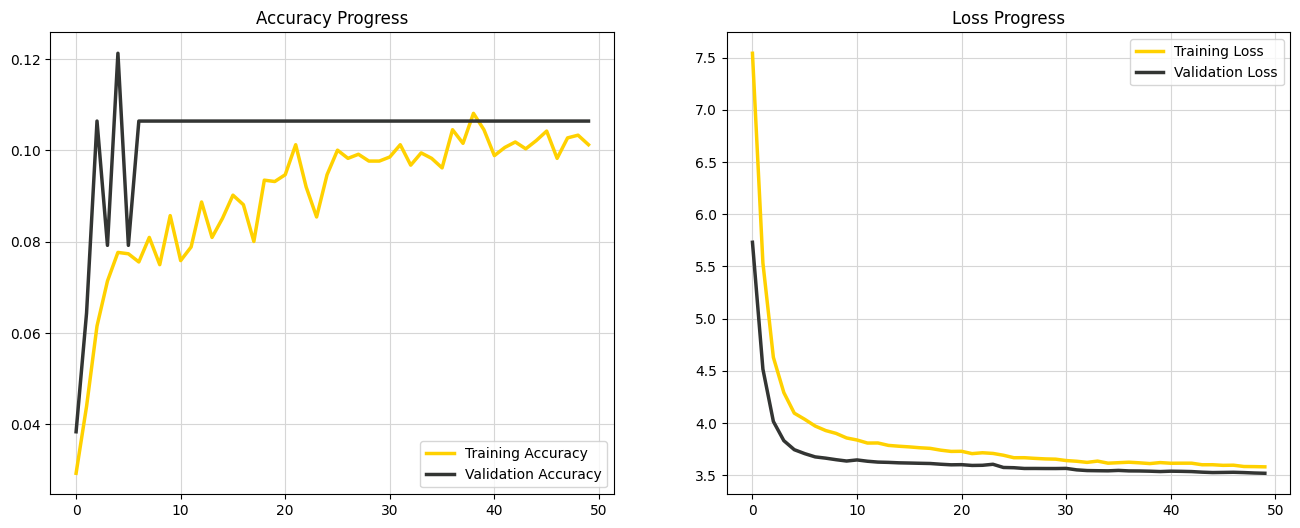

In [8]:
# Cell 7: Plotting Results
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#FFD100', linewidth=2.5)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#333533', linewidth=2.5)
    plt.legend(loc='lower right')
    plt.title('Accuracy Progress')
    plt.grid(True, color='#D6D6D6')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#FFD100', linewidth=2.5)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#333533', linewidth=2.5)
    plt.legend(loc='upper right')
    plt.title('Loss Progress')
    plt.grid(True, color='#D6D6D6')
    
    plt.show()

plot_training_history(history)

## 🗣️ Step 8: Natural Language Processing (NLP) & Audio Synthesis (TTS) Layer

In a real-world driving scenario, a visual prediction (e.g., Outputting Class "14") is useless to a driver who must keep their eyes on the road. This cell bridges the gap between pure Computer Vision and Human-Computer Interaction (HCI) by introducing a Natural Language Processing (NLP) logic layer coupled with an Audio Synthesis module.

In [9]:
# Cell 8: NLP and Audio Modules

class NLPProcessor:
    def __init__(self, language='en'):
        self.language = language
        self.labels_dict = {}
        self._load_labels()

    def _load_labels(self):
        try:
            labels_path = os.path.join(KAGGLE_INPUT_PATH, "labels.csv")
            df = pd.read_csv(labels_path)
            
            class_col = df.columns[0]
            name_col = df.columns[1]
            
            folders = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
            
            for model_index, folder_name in enumerate(folders):
                try:
                    class_id = int(folder_name)
                    sign_name = df[df[class_col] == class_id][name_col].values[0]
                    
                    self.labels_dict[model_index] = f"{sign_name} ahead. Please pay attention."
                except Exception as inner_e:
                    self.labels_dict[model_index] = f"Traffic sign {folder_name} detected."
                    
            print(f"✅ Loaded {len(self.labels_dict)} labels successfully from labels.csv.")
            
        except Exception as e:
            print(f"⚠️ Warning: Could not read labels.csv. Error: {e}")
            self.labels_dict = {}

    def generate_sentence(self, class_index):
        if class_index in self.labels_dict:
            return self.labels_dict[class_index]
        return f"Traffic sign of class {class_index} detected, please pay attention."

class TTSAudioEngine:
    def __init__(self, language='en'):
        self.language = language

    def speak(self, text, filename="output_audio.mp3"):
        try:
            tts = gTTS(text=text, lang=self.language, slow=False)
            tts.save(filename)
            display(Audio(filename, autoplay=True))
        except Exception as e:
            print(f"Audio Error: {e}")

## 🚀 Step 9: End-to-End System Simulation Pipeline (Inference)

In this final testing phase, we construct an end-to-end inference pipeline to simulate how the **VisionMaroor** system will operate in a real-world driving environment. This function integrates all previously built modules into a single, cohesive lifecycle.

✅ Loaded 58 labels successfully from labels.csv.
🔍 Image loaded from: /kaggle/input/datasets/seebicb/traffic-signs-classification/traffic_Data/test/28/028_1_0214.png


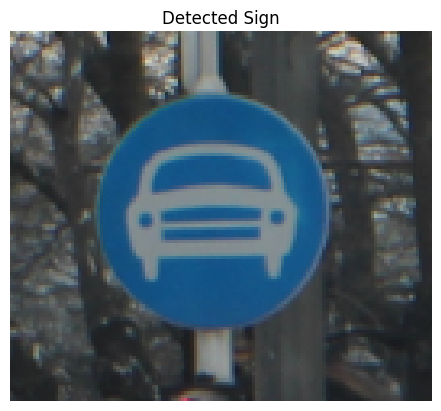

2026-03-01 23:22:31.793299: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 23:22:31.929809: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 23:22:32.646843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 23:22:32.783128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
🚦 Predicted Class ID: 21
📝 Output Text : watch out for cars ahead. Please pay attention.


In [10]:
# Cell 9: System Simulation Pipeline

def simulate_vision_maroor():
    # 1. Verify Model Existence
    if not os.path.exists(MODEL_SAVE_PATH):
        print("Model file not found! Please ensure Cell 5 completed training.")
        return

    saved_model = load_model(MODEL_SAVE_PATH)
    nlp = NLPProcessor(language='en')
    tts = TTSAudioEngine(language='en')

    # 2. Deep Recursive Search for Test Images
    test_images = []
    # Including all possible image extensions
    valid_extensions = ('.png', '.jpg', '.jpeg', '.ppm', '.bmp') 
    
    for root, dirs, files in os.walk(TEST_DIR):
        for file in files:
            if file.lower().endswith(valid_extensions):
                test_images.append(os.path.join(root, file))
                
    if not test_images:
        print(f"❌ Could not find any images in the directory or its subfolders: {TEST_DIR}")
        return

    # Select a random image
    image_path = random.choice(test_images)
    print(f"🔍 Image loaded from: {image_path}")

    # 3. Display the Image
    img_display = cv2.imread(image_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    plt.imshow(img_display)
    plt.title("Detected Sign")
    plt.axis('off')
    plt.show()

    # 4. Image Preprocessing and Prediction
    img = image.load_img(image_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = saved_model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]
    
    # 5. Text and Audio Generation
    sentence = nlp.generate_sentence(predicted_class)
    print("="*50)
    print(f"🚦 Predicted Class ID: {predicted_class}")
    print(f"📝 Output Text : {sentence}")
    print("="*50)
    
    tts.speak(sentence)

# Run the Simulation
simulate_vision_maroor()